<a href="https://colab.research.google.com/github/tenacioussami/NLP/blob/main/Time_Series_Analysis_Electric_Production.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Time Series Analysis – Electric Production

**Instructor:** Md. Samiul Islam  
**Organization:** Skill Morph Research Lab

In [14]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Load Dataset

In [15]:
# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/datasets/Electric_Production.csv')

# Parse date column
df['DATE'] = pd.to_datetime(df['DATE'])

# Set Date as index
df.set_index('DATE', inplace=True)

# Sort by time
df.sort_index(inplace=True)

# Handle missing values
df.dropna(inplace=True)

print("Dataset loaded successfully!")
print(f"Data range: {df.index[0]} to {df.index[-1]}")

Dataset loaded successfully!
Data range: 1985-01-01 00:00:00 to 2018-01-01 00:00:00


## Data Overview

In [16]:
# Display first few rows
print(df.head())
print("\n" + "="*50 + "\n")

# Dataset info
print(df.info())
print("\n" + "="*50 + "\n")

# Basic statistics
print(df.describe())

              Value
DATE               
1985-01-01  72.5052
1985-02-01  70.6720
1985-03-01  62.4502
1985-04-01  57.4714
1985-05-01  55.3151


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 397 entries, 1985-01-01 to 2018-01-01
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Value   397 non-null    float64
dtypes: float64(1)
memory usage: 6.2 KB
None


            Value
count  397.000000
mean    88.847218
std     15.387834
min     55.315100
25%     77.105200
50%     89.779500
75%    100.524400
max    129.404800


## Time Series Visualization

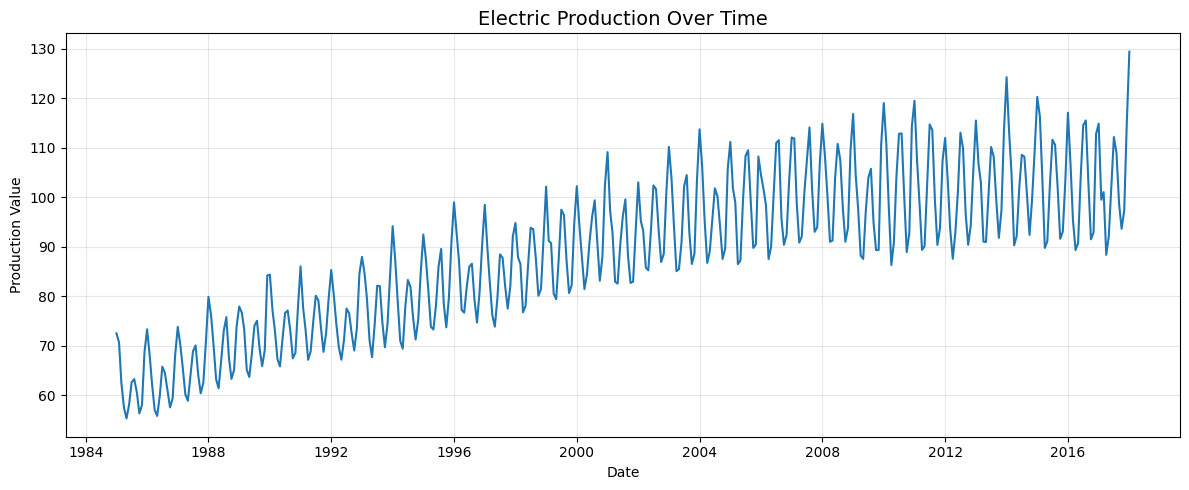

In [17]:
# Plot the time series
plt.figure(figsize=(12, 5))
plt.plot(df.index, df['Value'], linewidth=1.5)
plt.title('Electric Production Over Time', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Production Value')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

##TASK 1 and 2

In [23]:
import pandas as pd
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Ensure datetime index
df.index = pd.to_datetime(df.index)

# Set monthly frequency
df = df.asfreq('MS')

# Train-test split
train = df[:-24]
test = df[-24:]

# ARIMA(2,1,2)
model = ARIMA(train, order=(2,1,2))
model_fit = model.fit()

forecast = model_fit.forecast(steps=len(test))

mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 4.146396384210013
RMSE: 5.407212280603377


## Train/Test Split
Last 12 months for testing, rest for training.

In [5]:
# Split into train and test sets
train = df[:-12]
test = df[-12:]

print(f"Training data: {train.index[0]} to {train.index[-1]}")
print(f"Test data: {test.index[0]} to {test.index[-1]}")
print(f"\nTrain size: {len(train)}, Test size: {len(test)}")

Training data: 1985-01-01 00:00:00 to 2017-01-01 00:00:00
Test data: 2017-02-01 00:00:00 to 2018-01-01 00:00:00

Train size: 385, Test size: 12


## Baseline 1: Naive Forecast
Forecast = last observed training value.

In [6]:
# Naive forecast: use last training value
naive_forecast = [train['Value'].iloc[-1]] * len(test)

# Evaluate
mae_naive = mean_absolute_error(test['Value'], naive_forecast)
rmse_naive = np.sqrt(mean_squared_error(test['Value'], naive_forecast))

print("Naive Forecast Results:")
print(f"MAE: {mae_naive:.4f}")
print(f"RMSE: {rmse_naive:.4f}")

Naive Forecast Results:
MAE: 14.1185
RMSE: 16.0312


## Baseline 2: Seasonal Naive Forecast
Forecast = value from 12 months ago.

In [7]:
# Seasonal naive forecast: use value from 12 months ago
seasonal_naive_forecast = train['Value'].iloc[-12:].values

# Evaluate
mae_seasonal = mean_absolute_error(test['Value'], seasonal_naive_forecast)
rmse_seasonal = np.sqrt(mean_squared_error(test['Value'], seasonal_naive_forecast))

print("Seasonal Naive Forecast Results:")
print(f"MAE: {mae_seasonal:.4f}")
print(f"RMSE: {rmse_seasonal:.4f}")

Seasonal Naive Forecast Results:
MAE: 4.4385
RMSE: 5.7470


## Stationarity Check
Using Augmented Dickey-Fuller (ADF) Test on training data.

In [8]:
# Perform ADF test
adf_result = adfuller(train['Value'])

print("ADF Test Results:")
print(f"Test Statistic: {adf_result[0]:.4f}")
print(f"p-value: {adf_result[1]:.4f}")
print(f"\nConclusion: {'Stationary' if adf_result[1] < 0.05 else 'Non-stationary'} (p<0.05 = stationary)")

ADF Test Results:
Test Statistic: -2.4593
p-value: 0.1257

Conclusion: Non-stationary (p<0.05 = stationary)


## SARIMAX Model
Fitting SARIMAX(1,1,1)(1,1,1,12) to capture seasonality.

In [9]:
# Fit SARIMAX model
model = SARIMAX(train['Value'],
                order=(1, 1, 1),
                seasonal_order=(1, 1, 1, 12))

model_fit = model.fit(disp=False)

# Generate forecast
forecast = model_fit.forecast(steps=len(test))

print("SARIMAX model fitted successfully!")

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


SARIMAX model fitted successfully!


## Model Evaluation & Visualization

SARIMAX Model Results:
MAE: 3.2542
RMSE: 4.6162


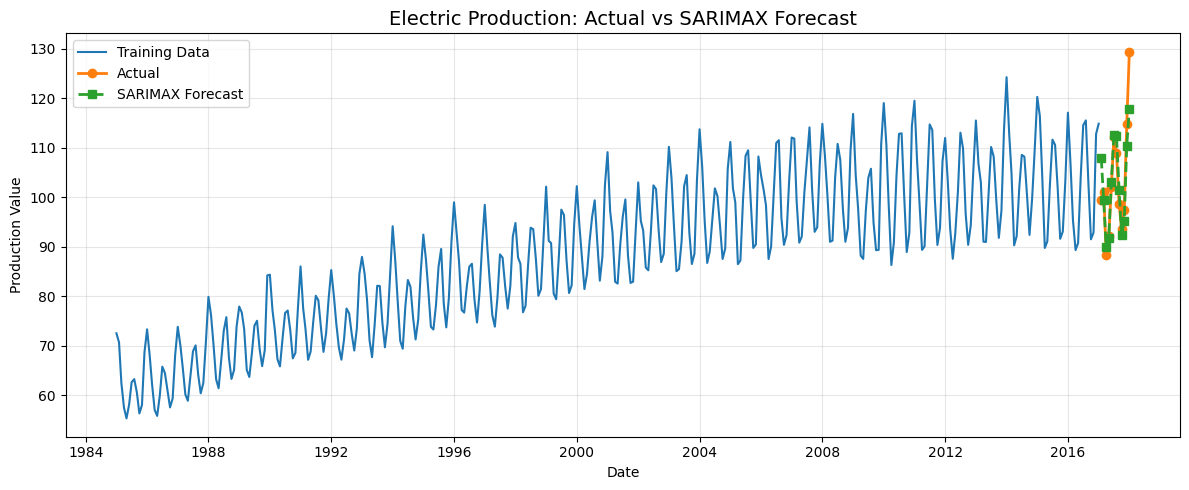


Model Comparison:
Naive Forecast       - MAE: 14.1185, RMSE: 16.0312
Seasonal Naive       - MAE: 4.4385, RMSE: 5.7470
SARIMAX Model        - MAE: 3.2542, RMSE: 4.6162


In [10]:
# Calculate metrics
mae_model = mean_absolute_error(test['Value'], forecast)
rmse_model = np.sqrt(mean_squared_error(test['Value'], forecast))

print("SARIMAX Model Results:")
print(f"MAE: {mae_model:.4f}")
print(f"RMSE: {rmse_model:.4f}")

# Plot actual vs forecast
plt.figure(figsize=(12, 5))
plt.plot(train.index, train['Value'], label='Training Data', linewidth=1.5)
plt.plot(test.index, test['Value'], label='Actual', linewidth=2, marker='o')
plt.plot(test.index, forecast, label='SARIMAX Forecast', linewidth=2, marker='s', linestyle='--')
plt.title('Electric Production: Actual vs SARIMAX Forecast', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Production Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Compare all models
print("\n" + "="*50)
print("Model Comparison:")
print("="*50)
print(f"Naive Forecast       - MAE: {mae_naive:.4f}, RMSE: {rmse_naive:.4f}")
print(f"Seasonal Naive       - MAE: {mae_seasonal:.4f}, RMSE: {rmse_seasonal:.4f}")
print(f"SARIMAX Model        - MAE: {mae_model:.4f}, RMSE: {rmse_model:.4f}")

##SARIMAX Perfomance is better.

## Assignment

**Task 1:** Try a different ARIMA order (e.g., (2,1,2) or (0,1,1)) and report MAE/RMSE.

**Task 2:** Change the test horizon to the last 24 months and compare results.

**Task 3:** Compare ARIMA/SARIMAX performance with the seasonal naive baseline. Which performs better?